# Ασαφή Σύνολα & Ασαφής Λογική
## Συναρτήσεις Συμμετοχής · Γλωσσικές Μεταβλητές · Ασαφείς Κανόνες

---

## 0. Εγκατάσταση βιβλιοθηκών
Εκτέλεσε το παρακάτω κελί μία φορά αν δεν έχεις ήδη εγκαταστήσει τις βιβλιοθήκες.

In [1]:
# !pip install numpy matplotlib ipywidgets
# Αποσχολίασε αν χρειαστεί

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interact, FloatSlider, Dropdown
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Βιβλιοθήκες φορτώθηκαν επιτυχώς.')

Βιβλιοθήκες φορτώθηκαν επιτυχώς.


---
## 1. Συναρτήσεις Συμμετοχής (Membership Functions)

Η συνάρτηση συμμετοχής `μ_A : X → [0,1]` εκφράζει τον **βαθμό** με τον οποίο ένα στοιχείο `x` ανήκει στο ασαφές σύνολο `A`:

| Τιμή | Ερμηνεία |
|------|----------|
| `μ(x) = 0` | Δεν ανήκει καθόλου |
| `0 < μ(x) < 1` | Μερική συμμετοχή |
| `μ(x) = 1` | Πλήρης συμμετοχή |

In [3]:
# ── Ορισμός συναρτήσεων συμμετοχής ──────────────────────────────────

def triangular(x, a, b, c):
    """Τριγωνική MF με κορυφή στο b."""
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    left  = (x > a) & (x <= b)
    right = (x > b) & (x < c)
    y[left]  = (x[left]  - a) / (b - a)
    y[right] = (c - x[right]) / (c - b)
    return y


def trapezoidal(x, a, b, c, d):
    """Τραπεζοειδής MF με πλατό [b, c]."""
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    y[(x >= b) & (x <= c)] = 1.0
    left  = (x > a) & (x < b)
    right = (x > c) & (x < d)
    y[left]  = (x[left]  - a) / (b - a)
    y[right] = (d - x[right]) / (d - c)
    return y


def gaussian(x, c, sigma):
    """Gaussian MF με κέντρο c και πλάτος sigma."""
    return np.exp(-0.5 * ((np.asarray(x, dtype=float) - c) / sigma) ** 2)


def sigmoid(x, k, c0):
    """Sigmoid MF με κλίση k και κέντρο c0."""
    return 1 / (1 + np.exp(-k * (np.asarray(x, dtype=float) - c0)))


print('Συναρτήσεις ορίστηκαν: triangular, trapezoidal, gaussian, sigmoid')

Συναρτήσεις ορίστηκαν: triangular, trapezoidal, gaussian, sigmoid


### 1.1 Σύγκριση και των 4 μορφών

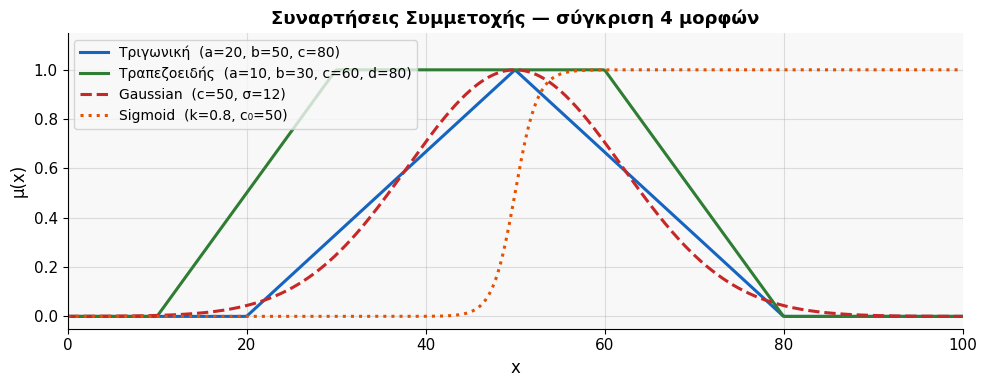

In [4]:
x = np.linspace(0, 100, 500)

configs = [
    ('Τριγωνική',    triangular(x, 20, 50, 80),  '#1565C0', '-',  'a=20, b=50, c=80'),
    ('Τραπεζοειδής', trapezoidal(x,10,30,60,80), '#2E7D32', '-',  'a=10, b=30, c=60, d=80'),
    ('Gaussian',     gaussian(x, 50, 12),         '#C62828', '--', 'c=50, σ=12'),
    ('Sigmoid',      sigmoid(x, 0.8, 50),         '#E65100', ':',  'k=0.8, c₀=50'),
]

fig, ax = plt.subplots(figsize=(10, 4))

for name, y, color, ls, params in configs:
    ax.plot(x, y, color=color, linestyle=ls, linewidth=2.2,
            label=f'{name}  ({params})')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('μ(x)', fontsize=12)
ax.set_title('Συναρτήσεις Συμμετοχής — σύγκριση 4 μορφών', fontsize=13, fontweight='bold')
ax.set_ylim(-0.05, 1.15)
ax.set_xlim(0, 100)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('membership_functions.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 Διαδραστική εξερεύνηση συνάρτησης συμμετοχής

In [5]:
x = np.linspace(0, 100, 500)

def plot_mf(mf_type, a_b_c=50.0, spread=15.0, d=80.0):
    fig, ax = plt.subplots(figsize=(9, 3.5))

    if mf_type == 'Τριγωνική':
        a = max(0, a_b_c - spread)
        c = min(100, a_b_c + spread)
        y = triangular(x, a, a_b_c, c)
        title = f'Τριγωνική: a={a:.0f}, b={a_b_c:.0f}, c={c:.0f}'
        color = '#1565C0'
    elif mf_type == 'Τραπεζοειδής':
        a = max(0, a_b_c - spread - 10)
        b = max(0, a_b_c - spread)
        c = min(100, a_b_c + spread)
        dd = min(100, a_b_c + spread + 10)
        y = trapezoidal(x, a, b, c, dd)
        title = f'Τραπεζοειδής: a={a:.0f}, b={b:.0f}, c={c:.0f}, d={dd:.0f}'
        color = '#2E7D32'
    elif mf_type == 'Gaussian':
        y = gaussian(x, a_b_c, spread)
        title = f'Gaussian: c={a_b_c:.0f}, σ={spread:.1f}'
        color = '#C62828'
    else:
        k = spread / 10
        y = sigmoid(x, k, a_b_c)
        title = f'Sigmoid: k={k:.2f}, c₀={a_b_c:.0f}'
        color = '#E65100'

    ax.fill_between(x, y, alpha=0.15, color=color)
    ax.plot(x, y, color=color, linewidth=2.5)
    ax.set_ylim(-0.05, 1.15)
    ax.set_xlim(0, 100)
    ax.set_xlabel('x'); ax.set_ylabel('μ(x)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

interact(
    plot_mf,
    mf_type=Dropdown(options=['Τριγωνική','Τραπεζοειδής','Gaussian','Sigmoid'],
                     description='Τύπος MF:'),
    a_b_c=FloatSlider(value=50, min=5, max=95, step=1, description='Κέντρο b/c₀:'),
    spread=FloatSlider(value=15, min=2, max=40, step=1, description='Εύρος σ:'),
)

interactive(children=(Dropdown(description='Τύπος MF:', options=('Τριγωνική', 'Τραπεζοειδής', 'Gaussian', 'Sig…

<function __main__.plot_mf(mf_type, a_b_c=50.0, spread=15.0, d=80.0)>

---
## 2. Γλωσσικές Μεταβλητές (Linguistic Variables)

Μια γλωσσική μεταβλητή αποτελείται από:
- **Όνομα**: π.χ. «Θερμοκρασία»
- **Σύμπαν ορισμού**: π.χ. [0°C, 45°C]
- **Γλωσσικοί όροι**: {Δροσερή, Μέτρια, Ζεστή, Καυτή}
- **Συναρτήσεις συμμετοχής**: μία για κάθε όρο

In [6]:
# ── Ορισμός γλωσσικών μεταβλητών ─────────────────────────────────────

x_temp = np.linspace(0, 45, 500)
x_hum  = np.linspace(0, 100, 500)

temp_terms = {
    'Δροσερή': (trapezoidal(x_temp, 0,  0, 18, 26), '#1565C0'),
    'Μέτρια':  (triangular( x_temp, 20, 27, 34),    '#2E7D32'),
    'Ζεστή':   (triangular( x_temp, 28, 34, 40),    '#F57C00'),
    'Καυτή':   (trapezoidal(x_temp, 36, 41, 45, 45),'#C62828'),
}

hum_terms = {
    'Χαμηλή': (trapezoidal(x_hum,  0,  0, 30, 50), '#1565C0'),
    'Μέτρια': (triangular( x_hum, 35, 55, 75),     '#2E7D32'),
    'Υψηλή':  (trapezoidal(x_hum, 60, 80,100,100), '#C62828'),
}

print('Γλωσσικές μεταβλητές ορίστηκαν: Θερμοκρασία, Υγρασία')

Γλωσσικές μεταβλητές ορίστηκαν: Θερμοκρασία, Υγρασία


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# -- Θερμοκρασία
ax = axes[0]
for term, (y, col) in temp_terms.items():
    ax.fill_between(x_temp, y, alpha=0.12, color=col)
    ax.plot(x_temp, y, color=col, linewidth=2, label=term)
ax.set_title('Γλωσσική μεταβλητή: Θερμοκρασία', fontweight='bold')
ax.set_xlabel('Θερμοκρασία (°C)'); ax.set_ylabel('μ(x)')
ax.set_ylim(-0.05, 1.15); ax.legend()

# -- Υγρασία
ax = axes[1]
for term, (y, col) in hum_terms.items():
    ax.fill_between(x_hum, y, alpha=0.12, color=col)
    ax.plot(x_hum, y, color=col, linewidth=2, label=term)
ax.set_title('Γλωσσική μεταβλητή: Υγρασία', fontweight='bold')
ax.set_xlabel('Υγρασία (%)'); ax.set_ylabel('μ(x)')
ax.set_ylim(-0.05, 1.15); ax.legend()

plt.suptitle('Γλωσσικές Μεταβλητές — Σύστημα Ελέγχου Κλιματιστικού',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('linguistic_variables.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.1 Διαδραστικό — βαθμός συμμετοχής για δοσμένη τιμή

In [ ]:
def plot_fuzzification(temp=32.0, hum=65.0):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, x_arr, terms, val, xlabel, title in [
        (axes[0], x_temp, temp_terms, temp, 'Θερμοκρασία (°C)', 'Fuzzification — Θερμοκρασία'),
        (axes[1], x_hum,  hum_terms,  hum,  'Υγρασία (%)',       'Fuzzification — Υγρασία'),
    ]:
        for term, (y, col) in terms.items():
            ax.fill_between(x_arr, y, alpha=0.12, color=col)
            ax.plot(x_arr, y, color=col, linewidth=2, label=term)

        ax.axvline(val, color='black', linewidth=1.5, linestyle='--', alpha=0.6, label=f'x = {val}')

        for term, (y, col) in terms.items():
            idx = np.argmin(np.abs(x_arr - val))
            mu  = y[idx]
            if mu > 0.01:
                ax.plot(val, mu, 'o', color=col, markersize=8)
                ax.annotate(f'  μ={mu:.2f}', (val, mu), fontsize=9, color=col)

        ax.set_title(title, fontweight='bold')
        ax.set_xlabel(xlabel); ax.set_ylabel('μ(x)')
        ax.set_ylim(-0.05, 1.2); ax.legend(fontsize=9)

    plt.tight_layout(); plt.show()

interact(
    plot_fuzzification,
    temp=FloatSlider(value=32, min=0,  max=45,  step=0.5, description='Θερμ. (°C):'),
    hum= FloatSlider(value=65, min=0,  max=100, step=1,   description='Υγρασία (%):'),
)

---
## 3. Ασαφείς Κανόνες (Fuzzy Rules) & Inference

Οι κανόνες έχουν μορφή **IF–THEN**:
```
ΑΝ θερμοκρασία = Ζεστή  ΚΑΙ  υγρασία = Υψηλή  ΤΟΤΕ  κλιματιστικό = Πλήρες
```

Η ενεργοποίηση κάθε κανόνα υπολογίζεται ως:
```
fire = min( μ_temp(x), μ_hum(x) )   ← Mamdani AND
```

Η τελική έξοδος προκύπτει με **Defuzzification** (σταθμισμένος μέσος).

In [ ]:
# ── Ορισμός κανόνων ───────────────────────────────────────────────────

# Γλωσσικοί όροι εξόδου (ισχύς κλιματιστικού 0–100%)
output_terms = {
    'Ανενεργό': 0,
    'Χαμηλό':   25,
    'Μέτριο':   50,
    'Δυνατό':   75,
    'Πλήρες':   100,
}

rules = [
    ('Δροσερή', 'Χαμηλή', 'Ανενεργό'),
    ('Δροσερή', 'Υψηλή',  'Χαμηλό'),
    ('Μέτρια',  'Χαμηλή', 'Χαμηλό'),
    ('Μέτρια',  'Μέτρια', 'Μέτριο'),
    ('Μέτρια',  'Υψηλή',  'Δυνατό'),
    ('Ζεστή',   'Μέτρια', 'Δυνατό'),
    ('Ζεστή',   'Υψηλή',  'Πλήρες'),
    ('Καυτή',   'Χαμηλή', 'Δυνατό'),
    ('Καυτή',   'Υψηλή',  'Πλήρες'),
]


def get_mu_temp(term, val):
    """Βαθμός συμμετοχής για θερμοκρασία."""
    fns = {
        'Δροσερή': lambda v: trapezoidal(np.array([v]), 0,  0, 18, 26)[0],
        'Μέτρια':  lambda v: triangular( np.array([v]), 20, 27, 34)[0],
        'Ζεστή':   lambda v: triangular( np.array([v]), 28, 34, 40)[0],
        'Καυτή':   lambda v: trapezoidal(np.array([v]), 36, 41, 45, 45)[0],
    }
    return fns[term](val)


def get_mu_hum(term, val):
    """Βαθμός συμμετοχής για υγρασία."""
    fns = {
        'Χαμηλή': lambda v: trapezoidal(np.array([v]),  0,  0, 30, 50)[0],
        'Μέτρια': lambda v: triangular( np.array([v]), 35, 55, 75)[0],
        'Υψηλή':  lambda v: trapezoidal(np.array([v]), 60, 80,100,100)[0],
    }
    return fns[term](val)


def fuzzy_inference(temp_val, hum_val, verbose=True):
    """Εκτελεί Mamdani inference και επιστρέφει την αποασαφοποιημένη έξοδο."""
    firings = []
    for t_term, h_term, out_term in rules:
        mt   = get_mu_temp(t_term, temp_val)
        mh   = get_mu_hum(h_term, hum_val)
        fire = min(mt, mh)
        firings.append((t_term, h_term, out_term, mt, mh, fire))

    if verbose:
        print(f"\nΕίσοδοι: Θερμοκρασία = {temp_val}°C, Υγρασία = {hum_val}%")
        print("-" * 72)
        print(f"{'Κανόνας':<42} {'μ_temp':>6} {'μ_hum':>6} {'fire':>6}")
        print("-" * 72)
        for t,h,o,mt,mh,f in firings:
            active = '●' if f > 0.01 else ' '
            print(f"{active} ΑΝ {t:<9} ΚΑΙ {h:<8} ΤΟΤΕ {o:<10} {mt:>6.3f} {mh:>6.3f} {f:>6.3f}")
        print("-" * 72)

    # Defuzzification — σταθμισμένος μέσος
    num = sum(f * output_terms[o] for _,_,o,_,_,f in firings)
    den = sum(f for *_,f in firings)
    output = num / den if den > 0 else 0

    if verbose:
        lbl = next((k for k,v in output_terms.items() if abs(v-output)<13), '—')
        print(f"\nΈξοδος (defuzzified): {output:.1f}%  →  {lbl}")

    return output, firings


_ = fuzzy_inference(32, 65)

### 3.1 Οπτικοποίηση κανόνων & αποτελέσματος

In [ ]:
def plot_inference(temp_val=32.0, hum_val=65.0):
    output, firings = fuzzy_inference(temp_val, hum_val, verbose=False)

    active = [(t,h,o,f) for t,h,o,_,_,f in firings if f > 0.01]
    n = max(len(active), 1)

    fig = plt.figure(figsize=(14, 3 + n * 0.9))
    rule_colors = {'Ανενεργό':'#888', 'Χαμηλό':'#1565C0',
                   'Μέτριο':'#2E7D32', 'Δυνατό':'#F57C00', 'Πλήρες':'#C62828'}

    # -- bar plot ενεργών κανόνων
    ax_rules = fig.add_axes([0.05, 0.15, 0.55, 0.75])
    labels = [f'ΑΝ {t} ΚΑΙ {h}\nΤΟΤΕ {o}' for t,h,o,_ in active]
    values = [f for *_,f in active]
    colors = [rule_colors.get(o, '#555') for _,_,o,_ in active]
    bars = ax_rules.barh(range(len(labels)), values, color=colors, alpha=0.75, height=0.6)
    ax_rules.set_yticks(range(len(labels)))
    ax_rules.set_yticklabels(labels, fontsize=10)
    ax_rules.set_xlim(0, 1.1)
    ax_rules.set_xlabel('Βαθμός ενεργοποίησης (fire strength)')
    ax_rules.set_title(f'Ενεργοί κανόνες  |  T={temp_val}°C, H={hum_val}%', fontweight='bold')
    for bar, val in zip(bars, values):
        ax_rules.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                      f'{val:.3f}', va='center', fontsize=9)

    # -- gauge έξοδος
    ax_out = fig.add_axes([0.68, 0.15, 0.28, 0.75])
    col = rule_colors[max(output_terms, key=lambda k: -abs(output_terms[k]-output))]
    ax_out.barh([0], [output], color=col, alpha=0.8, height=0.5)
    ax_out.barh([0], [100], color='#eee', alpha=0.5, height=0.5)
    ax_out.set_xlim(0, 110)
    ax_out.set_yticks([])
    ax_out.set_xlabel('Ισχύς κλιματιστικού (%)')
    ax_out.set_title('Έξοδος (defuzzified)', fontweight='bold')
    ax_out.text(output/2, 0, f'{output:.1f}%', ha='center', va='center',
                fontsize=16, fontweight='bold', color='white')
    for k, v in output_terms.items():
        ax_out.axvline(v, color='gray', linewidth=0.5, linestyle=':')
        ax_out.text(v, -0.45, k, ha='center', fontsize=8, color='gray', rotation=30)

    plt.savefig('fuzzy_inference.png', dpi=150, bbox_inches='tight')
    plt.show()

interact(
    plot_inference,
    temp_val=FloatSlider(value=32, min=0,  max=45,  step=0.5, description='Θερμ. (°C):'),
    hum_val= FloatSlider(value=65, min=0,  max=100, step=1,   description='Υγρασία (%):'),
)

---
## 4. Επιφάνεια Απόκρισης (Control Surface)

Η επιφάνεια απόκρισης δείχνει την έξοδο του συστήματος για **όλους** τους συνδυασμούς εισόδων.

In [ ]:
temps = np.linspace(0, 45, 60)
hums  = np.linspace(0, 100, 60)
T, H  = np.meshgrid(temps, hums)
Z     = np.zeros_like(T)

for i in range(T.shape[0]):
    for j in range(T.shape[1]):
        Z[i, j], _ = fuzzy_inference(T[i,j], H[i,j], verbose=False)

fig = plt.figure(figsize=(13, 5))

# 3D
ax3d = fig.add_subplot(121, projection='3d')
surf = ax3d.plot_surface(T, H, Z, cmap='RdYlBu_r', alpha=0.85, linewidth=0)
ax3d.set_xlabel('Θερμοκρασία (°C)', labelpad=8)
ax3d.set_ylabel('Υγρασία (%)', labelpad=8)
ax3d.set_zlabel('Ισχύς (%)', labelpad=8)
ax3d.set_title('Επιφάνεια Απόκρισης (3D)', fontweight='bold')
fig.colorbar(surf, ax=ax3d, shrink=0.5, label='Ισχύς %')

# 2D contour
ax2d = fig.add_subplot(122)
cp = ax2d.contourf(T, H, Z, levels=20, cmap='RdYlBu_r')
ax2d.contour(T, H, Z, levels=20, colors='white', linewidths=0.4, alpha=0.4)
fig.colorbar(cp, ax=ax2d, label='Ισχύς %')
ax2d.set_xlabel('Θερμοκρασία (°C)')
ax2d.set_ylabel('Υγρασία (%)')
ax2d.set_title('Επιφάνεια Απόκρισης (2D)', fontweight='bold')

plt.tight_layout()
plt.savefig('control_surface.png', dpi=150, bbox_inches='tight')
plt.show()
print('Αρχεία PNG αποθηκεύτηκαν στον τρέχοντα φάκελο.')

---
## 5. Σύνοψη

| Έννοια | Περιγραφή |
|--------|-----------|
| **Συνάρτηση συμμετοχής** | Μετρά τον βαθμό ανήκειν στο [0,1] |
| **Γλωσσική μεταβλητή** | Σύνολο ασαφών όρων (π.χ. Κρύα, Ζεστή) |
| **Ασαφής κανόνας** | IF–THEN σε φυσική γλώσσα |
| **Fuzzification** | Κριτή τιμή → βαθμοί συμμετοχής |
| **Inference** | Εφαρμογή κανόνων (Mamdani AND = min) |
| **Defuzzification** | Βαθμοί συμμετοχής → κριτή τιμή εξόδου |

### Επόμενα βήματα
- Δοκίμασε διαφορετικές μορφές MF (gaussian αντί τριγωνικής)
- Πρόσθεσε μια 3η είσοδο (π.χ. ώρα ημέρας)
- Εξερεύνησε το `scikit-fuzzy` για έτοιμα FIS